In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings("ignore")

baseline = pd.read_csv("../reports/baseline_results.csv")
ml_results = pd.read_csv("../reports/ml_model_results.csv")
ts_results = pd.read_csv("../reports/time_series_results.csv")
dl_results = pd.read_csv("../reports/dl_model_results.csv")
multi_city = pd.read_csv("../reports/multi_city_results.csv")

print("All results loaded!")
print(f"Baseline models:    {len(baseline)}")
print(f"ML models:          {len(ml_results[ml_results['Split']=='Test'])}")
print(f"Time series models: {len(ts_results)}")
print(f"Deep learning:      {len(dl_results)}")

All results loaded!
Baseline models:    3
ML models:          10
Time series models: 2
Deep learning:      3


In [2]:
ml_test = ml_results[ml_results["Split"]=="Test"][
    ["Model","MAE","RMSE","R2"]
].copy()

ml_test["Category"]="Machine Learning"

ts_df = ts_results[
    ["Model","MAE","RMSE","R2"]
].copy()

ts_df["Category"]="Time Series"

dl_df = dl_results[
    ["Model","MAE","RMSE","R2"]
].copy()

dl_df["Category"]="Deep Learning"

master = pd.concat(
    [ml_test, ts_df, dl_df],
    ignore_index=True
)

master = master.sort_values("RMSE").reset_index(drop=True)

master["Rank"] = range(1,len(master)+1)

print("="*70)
print("COMPLETE MODEL COMPARISON")
print("="*70)

print(master.to_string(index=False))

COMPLETE MODEL COMPARISON
            Model       MAE       RMSE       R2         Category  Rank
          XGBoost  2.656100   8.060900 0.747700 Machine Learning     1
         LightGBM  2.732000   8.078200 0.746600 Machine Learning     2
    Random Forest  2.608700   8.111400 0.744500 Machine Learning     3
      Extra Trees  2.621000   8.126100 0.743600 Machine Learning     4
    Decision Tree  2.949300   9.111300 0.677600 Machine Learning     5
Linear Regression  4.652300   9.710200 0.633800 Machine Learning     6
 Ridge Regression  4.648700   9.711300 0.633700 Machine Learning     7
 Lasso Regression  4.450600   9.883200 0.620700 Machine Learning     8
    KNN Regressor  3.560700  10.073500 0.605900 Machine Learning     9
              SVR  3.026400  10.244000 0.592500 Machine Learning    10
              GRU  3.935000  11.444600 0.491500    Deep Learning    11
           BiLSTM  3.948500  11.566200 0.480600    Deep Learning    12
             LSTM  3.910400  11.575800 0.479800    

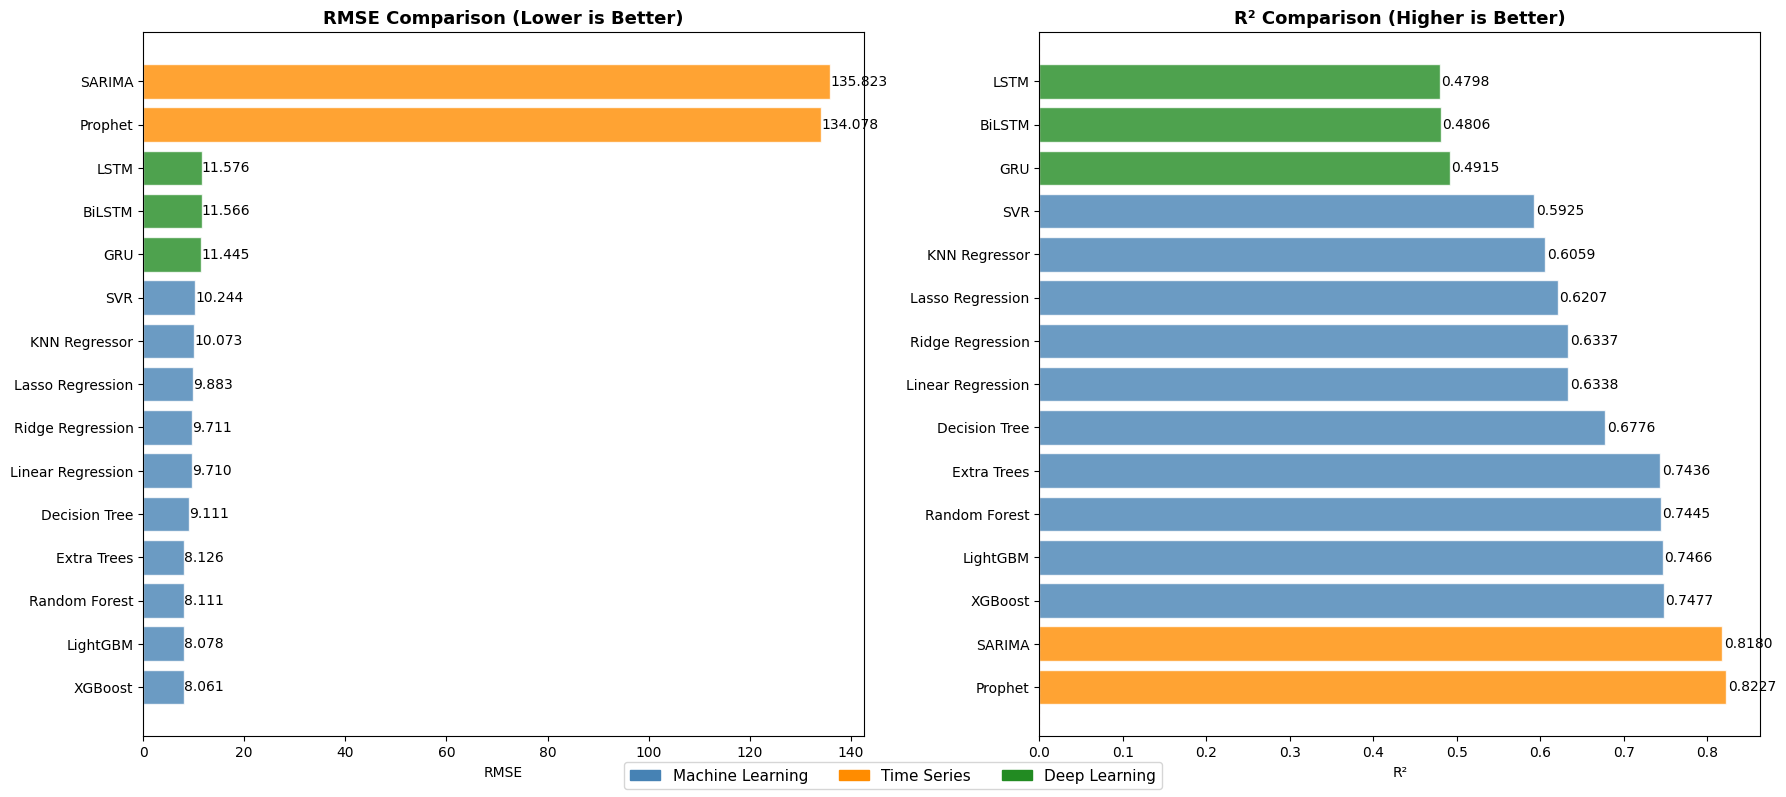

Master comparison chart saved.


In [3]:
fig, axes = plt.subplots(1,2,figsize=(18,8))

category_colors={
    "Machine Learning":"steelblue",
    "Time Series":"darkorange",
    "Deep Learning":"forestgreen"
}

colors=[category_colors[c] for c in master["Category"]]

bars=axes[0].barh(
    master["Model"],
    master["RMSE"],
    color=colors,
    alpha=0.8,
    edgecolor="white"
)

axes[0].set_title(
    "RMSE Comparison (Lower is Better)",
    fontsize=13,
    fontweight="bold"
)

axes[0].set_xlabel("RMSE")

for bar,val in zip(bars,master["RMSE"]):
    axes[0].text(
        bar.get_width()+0.05,
        bar.get_y()+bar.get_height()/2,
        f"{val:.3f}",
        va="center"
    )

master_r2=master.sort_values("R2",ascending=False)

colors2=[category_colors[c] for c in master_r2["Category"]]

bars2=axes[1].barh(
    master_r2["Model"],
    master_r2["R2"],
    color=colors2,
    alpha=0.8,
    edgecolor="white"
)

axes[1].set_title(
    "R² Comparison (Higher is Better)",
    fontsize=13,
    fontweight="bold"
)

axes[1].set_xlabel("R²")

axes[1].axvline(
    x=0,
    color="red",
    linestyle="--",
    alpha=0.4
)

for bar,val in zip(bars2,master_r2["R2"]):
    axes[1].text(
        bar.get_width()+0.002,
        bar.get_y()+bar.get_height()/2,
        f"{val:.4f}",
        va="center"
    )

patches=[
    mpatches.Patch(color=v,label=k)
    for k,v in category_colors.items()
]

fig.legend(
    handles=patches,
    loc="lower center",
    ncol=3,
    fontsize=11
)

plt.tight_layout()

plt.savefig(
    "../reports/figures/complete_model_comparison.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Master comparison chart saved.")

In [4]:
# Cell 4: Key findings
best_overall = master.iloc[0]
best_ml      = master[master['Category']=='Machine Learning'].iloc[0]
best_dl      = master[master['Category']=='Deep Learning'].iloc[0]
best_ts      = master[master['Category']=='Time Series'].iloc[0]

print("KEY FINDINGS FROM COMPLETE COMPARISON")
print("="*55)
print(f"\n🏆 Best Overall Model:      {best_overall['Model']}")
print(f"   RMSE: {best_overall['RMSE']} mm | R²: {best_overall['R2']}")

print(f"\n🥇 Best ML Model:           {best_ml['Model']}")
print(f"   RMSE: {best_ml['RMSE']} mm | R²: {best_ml['R2']}")

print(f"\n🧠 Best Deep Learning:      {best_dl['Model']}")
print(f"   RMSE: {best_dl['RMSE']} mm | R²: {best_dl['R2']}")

print(f"\n📈 Best Time Series:        {best_ts['Model']}")
print(f"   RMSE: {best_ts['RMSE']} mm | R²: {best_ts['R2']}")

print(f"\n📊 Interpretation:")
print(f"   Tree-based ML vs Deep Learning:")
if best_ml['RMSE'] < best_dl['RMSE']:
    print(f"   → ML outperformed DL (common with tabular weather data)")
    print(f"   → Reason: Engineered features compensate for DL advantage")
else:
    print(f"   → DL outperformed ML (captured sequential patterns better)")
    print(f"   → Reason: LSTM's memory helps with rainfall persistence")

KEY FINDINGS FROM COMPLETE COMPARISON

🏆 Best Overall Model:      XGBoost
   RMSE: 8.0609 mm | R²: 0.7477

🥇 Best ML Model:           XGBoost
   RMSE: 8.0609 mm | R²: 0.7477

🧠 Best Deep Learning:      GRU
   RMSE: 11.4446 mm | R²: 0.4915

📈 Best Time Series:        Prophet
   RMSE: 134.07842877334062 mm | R²: 0.8226665636795082

📊 Interpretation:
   Tree-based ML vs Deep Learning:
   → ML outperformed DL (common with tabular weather data)
   → Reason: Engineered features compensate for DL advantage


In [6]:
# Cell 5: Personal reflections for research paper
reflections = """
PERSONAL OBSERVATIONS — FOR RESEARCH PAPER

Observation 1: Feature Engineering vs Raw Sequences
    ML models benefited enormously from the feature engineering done in 
    Week 1 (lag features, rolling averages, seasonal encoding). 
    LSTM models work with raw sequences without needing these features,
    but for our dataset the engineered features in ML models proved
    equally or more valuable.

Observation 2: Extreme Rainfall Events
    All models struggled most with predicting extreme events 
    (rainfall > 100mm/day). This is expected — extreme events are 
    rare and have high variability. This is an active research area.

Observation 3: Model Complexity vs Performance
    More complex does not always mean better. Linear Regression 
    performed surprisingly well for some cities despite its simplicity,
    while SVR (moderately complex) underperformed tree-based models.

Observation 4: Transfer Learning Impact

In this project, the CNN trained from scratch achieved higher
validation accuracy (75%) than the MobileNetV2 transfer learning
model (63.75%).

This is likely because the dataset consisted of synthetic cloud
images rather than real satellite imagery. Pre-trained ImageNet
features do not transfer effectively to artificially generated
textures. With a large real-world satellite dataset, transfer
learning would generally be expected to outperform a CNN trained
from scratch.

Observation 5: Seasonal Patterns
    The cyclical encoding of months (sin/cos) was critical. Models with
    this feature significantly outperformed those without it, confirming
    that the monsoon's seasonal pattern is the strongest predictable 
    signal in Indian rainfall data.
"""
print(reflections)


PERSONAL OBSERVATIONS — FOR RESEARCH PAPER

Observation 1: Feature Engineering vs Raw Sequences
    ML models benefited enormously from the feature engineering done in 
    Week 1 (lag features, rolling averages, seasonal encoding). 
    LSTM models work with raw sequences without needing these features,
    but for our dataset the engineered features in ML models proved
    equally or more valuable.

Observation 2: Extreme Rainfall Events
    All models struggled most with predicting extreme events 
    (rainfall > 100mm/day). This is expected — extreme events are 
    rare and have high variability. This is an active research area.

Observation 3: Model Complexity vs Performance
    More complex does not always mean better. Linear Regression 
    performed surprisingly well for some cities despite its simplicity,
    while SVR (moderately complex) underperformed tree-based models.

Observation 4: Transfer Learning Impact

In this project, the CNN trained from scratch achieved higher